In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [4]:
data = pd.read_csv("F:/01. The Data Psychology/4. New_Machine_Learning/4. Naive Bay's/04. Placement Data.xls")

In [5]:
data

,Unnamed: 0,grade,cgpa,iq,communication,technical_knowledge,placement
0,0,B,7.34,124,1,7,0
1,1,D,8.88,112,1,5,0
2,2,C,7.95,85,8,8,0
3,3,B,6.42,103,8,8,1
4,4,A,6.10,98,6,9,1
...,...,...,...,...,...,...,...
495,495,B,6.47,116,7,10,1
496,496,B,6.51,126,8,9,1
497,497,A,8.04,116,3,6,1
498,498,D,7.68,91,5,5,0


In [6]:
if 'Unnamed: 0' in data.columns:
    data = data.drop('Unnamed: 0', axis=1)

In [7]:
print("Missing values:\n", data.isnull().sum())

Missing values:
 grade                  0
cgpa                   0
iq                     0
communication          0
technical_knowledge    0
placement              0
dtype: int64


In [8]:
data.duplicated().sum()

0

In [9]:
le = LabelEncoder()

data['grade'] = le.fit_transform(data['grade'])

In [10]:
data.head()

,grade,cgpa,iq,communication,technical_knowledge,placement
0,1,7.34,124,1,7,0
1,3,8.88,112,1,5,0
2,2,7.95,85,8,8,0
3,1,6.42,103,8,8,1
4,0,6.10,98,6,9,1


In [11]:
data.describe()

,grade,cgpa,iq,communication,technical_knowledge,placement
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1.110000,7.007540,109.786000,5.344000,5.626000,0.496000
std,0.967353,1.006612,17.363848,2.852707,2.810324,0.500485
min,0.000000,4.300000,80.000000,1.000000,1.000000,0.000000
25%,0.000000,6.350000,94.000000,3.000000,3.000000,0.000000
50%,1.000000,6.970000,110.000000,5.000000,6.000000,0.000000
75%,2.000000,7.662500,124.000000,8.000000,8.000000,1.000000
max,3.000000,10.000000,140.000000,10.000000,10.000000,1.000000


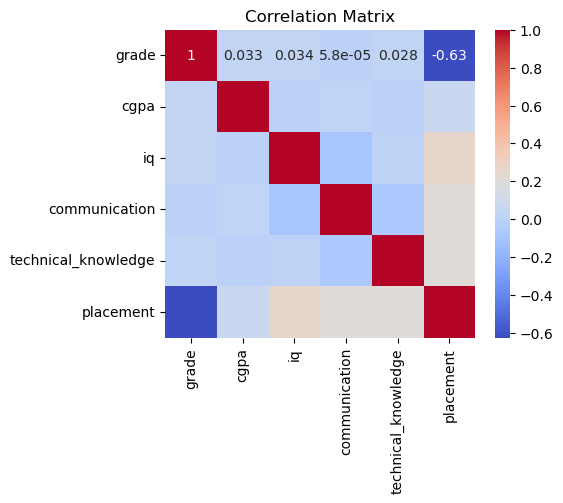

In [13]:
plt.figure(figsize=(5, 4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [14]:
X = data.drop('placement', axis=1)
y = data['placement']

In [15]:
X.head()

,grade,cgpa,iq,communication,technical_knowledge
0,1,7.34,124,1,7
1,3,8.88,112,1,5
2,2,7.95,85,8,8
3,1,6.42,103,8,8
4,0,6.10,98,6,9


In [16]:
y.head()

0    0
1    0
2    0
3    1
4    1
Name: placement, dtype: int64

In [17]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [18]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((400, 5), (100, 5), (400,), (100,))

In [22]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)


In [23]:
x_train_scale

array([[ 0.91303697, -1.64276431,  1.18743074, -1.51953767,  1.19880545],
       [-1.14451114,  1.07436486, -1.66683005,  0.57397003,  0.48997739],
       [-1.14451114,  0.62483981,  0.31367744, -1.51953767, -0.92767872],
       ...,
       [-0.11573708,  1.03440708, -0.09407411,  0.92288798,  0.84439142],
       [ 0.91303697,  1.41400601,  0.37192766, -0.12386587,  1.19880545],
       [-0.11573708,  1.69371048, -1.08432785, -1.51953767,  0.84439142]])

In [24]:
nb_model = GaussianNB()

nb_model.fit(x_train_scale, y_train)

,priors,None
,var_smoothing,1e-09


In [25]:
nb_model.score(x_test_scale,y_test)

0.83

In [26]:
y_pred = nb_model.predict(x_test_scale)

In [27]:
pd.DataFrame({"y_true":y_test, "y_pred":y_pred})

,y_true,y_pred
361,0,1
73,1,0
374,1,1
155,1,1
104,0,0
...,...,...
347,0,1
86,0,0
75,0,0
438,0,0


In [28]:
cm = confusion_matrix(y_test, y_pred)

In [29]:
cm

array([[38, 13],
       [ 4, 45]], dtype=int64)

In [30]:
accuracy = accuracy_score(y_test, y_pred)

In [31]:
accuracy

0.83

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82        51
           1       0.78      0.92      0.84        49

    accuracy                           0.83       100
   macro avg       0.84      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100



In [34]:
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=10)
}

In [35]:
grid_search = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='accuracy')

In [36]:
grid_search.fit(x_train_scale, y_train)

,estimator,GaussianNB()
,param_grid,"{'var_smoothing': array([1.e+00...e-08, 1.e-09])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [40]:
best_model = grid_search.best_estimator_

In [41]:
grid_search.best_params_

{'var_smoothing': 1.0}

In [42]:
 grid_search.best_score_

0.8549999999999999

In [46]:
y_pred_tuned = best_model.predict(x_test_scale)

In [47]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

In [48]:
tuned_accuracy

0.83

In [49]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82        51
           1       0.78      0.92      0.84        49

    accuracy                           0.83       100
   macro avg       0.84      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100



In [50]:
joblib.dump(best_model, 'naive_bayes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [57]:
unseen_data = pd.DataFrame({
    'grade': ['C'],
    'cgpa': [7.5],
    'iq': [60],
    'communication': [6],
    'technical_knowledge': [7]
})

In [58]:
unseen_data

,grade,cgpa,iq,communication,technical_knowledge
0,C,7.5,60,6,7


In [59]:
unseen_data['grade'] = le.transform(unseen_data['grade'])

unseen_data_scaled = scaler.transform(unseen_data)

In [60]:
unseen_data_scaled

array([[ 0.91303697,  0.50496647, -2.89008468,  0.22505208,  0.48997739]])

In [61]:
prediction = best_model.predict(unseen_data_scaled)

In [62]:
prediction

array([0], dtype=int64)